In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation
import numpy as np
import sys
import argparse
import os
import glob
import utils_report as ru
import utils_behavior as ub
from utils_behavior import calculate_polarization, calculate_cohesion, theil_index
import cfg
from utils_features import add_hunting

# Check if we're in interactive mode or batch mode
batchmode = False
if "ipykernel_launcher" in sys.argv[0]:
    print("Interactive mode")
else:
    batchmode = True
    print("Batch/CLI mode")
    # Parses the command line arguments below


def get_latest_flat_pkl_file(input_dir="./"):
    pkl_files = glob.glob(input_dir + "/*.pkl")
    pkl_files = [f for f in pkl_files if "flat" in f]
    if not pkl_files:
        raise FileNotFoundError("No .pkl files found in the current directory.")
    latest_pkl_file = max(pkl_files, key=os.path.getctime)
    return latest_pkl_file

default_dir = "/home/raaghav/zfish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check/"
if not os.path.exists(default_dir): # Running on cluster
    default_dir = "/n/home04/ramalik/ZFish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check"

# outputs_folder = "/srv/marl/raaghav/marl_zfish/rmappo-MultiAgentForagingEnv-1_agent/20250814_153603_1_bao_vd_0.003_fd_10_action_noise_0.1/outputs/"
# outputs_folder = "/home/raaghav/zfish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/outputs"
# outputs_folder = "/home/raaghav/zfish/onpolicy/custom/forage/results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/additional_exps"
outputs_folder = "./results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/outputs"

# ru.get_latest_outputs_folder(default_dir)
# "/srv/marl/satsingh/marl_fish/20241106_182038/outputs/"  # with biting
# "/home/satsingh/srv/marl/satsingh/marl_fish/rmappo-MultiAgentFishEnv-114/outputs/"  # GOOD
# "/home/satsingh/srv/marl/satsingh/marl_fish/20241013_202859/outputs"  # same as rmappo-MultiAgentFishEnv-114
#     "/home/satsingh/srv/marl/satsingh/marl_fish/20241013_202859/outputs/" # BEST
#     "/home/satsingh/srv/marl/satsingh/marl_fish/20241016_202055/outputs/" # OK
#     "/home/satsingh/srv/marl/satsingh/marl_fish/20241016_202056/outputs/" # OK
#     "/home/satsingh/srv/marl/satsingh/marl_fish/20241016_202053/outputs/" # OK

if batchmode:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "outputs_folder",
        default=outputs_folder,
        nargs="?",
    )
    args = parser.parse_args()
    outputs_folder = args.outputs_folder

print(f"Using outputs folder: {outputs_folder}")

flat_pkl_file = get_latest_flat_pkl_file(outputs_folder)
print(f"Using .pkl file: {flat_pkl_file}")

dff = pd.read_pickle(flat_pkl_file)
# ru.print_column_shapes(dff)
print("dff.shape", dff.shape)
print("dff.columns", dff.columns)

Interactive mode
Using outputs folder: ./results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/outputs
Using .pkl file: ./results/rmappo-MultiAgentForagingEnv-check/20250808_153214_1_bao_efp_0.05_vd_0.002_fd_10/outputs\MAZFish_neural_20250808_153214_bao_efp_0.05_vd_0.002_fd_10_agg_flattened.pkl
dff.shape (116000, 45)
dff.columns Index(['episode_index', 'time_step', 'agent_id', 'actions', 'observations',
       'rnn_states', 'rewards', 'attn_mask', 'env_id', 'position',
       'orientation', 'left_eye_angle', 'right_eye_angle', 'energy',
       'has_nearby', 'collided', 'detected_food_ids', 'eaten_food_ids',
       'cumulative_reward', 'food_positions', 'food_ids', 'arena_type',
       'arena_size', 'patch_kwargs.arena_size', 'patch_kwargs.arena_shape',
       'patch_kwargs.arena_radius', 'patch_kwargs.reset_food_density',
       'patch_kwargs.step_food_density', 'patch_kwargs.step_food_decay',
       'patch_kwargs.max_food_density', 'patch_kwargs.stoc

In [17]:
dff = dff.sort_values(
    by=["env_id", "episode_index", "agent_id", "time_step"]
).reset_index(drop=True)

print(dff.head())

   episode_index  time_step  agent_id                                actions  \
0              1          0         0  [-0.98870915, 0.43803963, 0.63978577]   
1              1          1         0  [-2.2243009, -0.06483698, -2.1473567]   
2              1          2         0   [0.87817544, -2.8888857, -1.4446247]   
3              1          3         0    [-2.7149925, -0.50928336, 1.762015]   
4              1          4         0       [5.683671, 2.4122388, -4.918922]   

                                        observations  \
0  [0.4558359810969221, 0.7925043988465813, 0.0, ...   
1  [0.4546557154607217, 0.7886861635804044, 0.0, ...   
2  [0.4542643347067528, 0.7884616931821549, 0.0, ...   
3  [0.4526703821650471, 0.7857694098121815, 0.0, ...   
4  [0.44828372514431636, 0.7794692715501894, 0.0,...   

                                          rnn_states   rewards attn_mask  \
0  [[-0.8260337710380554, 0.7414625883102417, -0.... -0.003078      None   
1  [[-0.6170010566711426, 0.98

In [9]:
# dff["move_forward"] = dff["move_forward"] * cfg.FISH_CONSTANTS["max_speed"]
# dff["turn_angle"] = dff["turn_angle"] * cfg.FISH_CONSTANTS["max_turn_speed"]

# # Compute vergence angle and speed
# perception_field = 163 * np.pi / 180
# dff['vergence_angle'] = dff['left_eye_angle'] - dff['right_eye_angle'] + perception_field
# dff['speed'] = dff['displacement'] * cfg.ENV_PARAMS["fps_sim"]

In [ ]:
# # Speed is calculated via displacement so has some bugs -- more interesting to look at move_forward

# dff['speed'] = dff['move_forward']
# dff['vergence_angle_deg'] = dff['vergence_angle'] * 180 / np.pi


In [18]:
dff.columns

Index(['episode_index', 'time_step', 'agent_id', 'actions', 'observations',
       'rnn_states', 'rewards', 'attn_mask', 'env_id', 'position',
       'orientation', 'left_eye_angle', 'right_eye_angle', 'energy',
       'has_nearby', 'collided', 'detected_food_ids', 'eaten_food_ids',
       'cumulative_reward', 'food_positions', 'food_ids', 'arena_type',
       'arena_size', 'patch_kwargs.arena_size', 'patch_kwargs.arena_shape',
       'patch_kwargs.arena_radius', 'patch_kwargs.reset_food_density',
       'patch_kwargs.step_food_density', 'patch_kwargs.step_food_decay',
       'patch_kwargs.max_food_density', 'patch_kwargs.stockpile_density',
       'patch_kwargs.drift', 'patch_kwargs.drag', 'move_forward', 'turn_angle',
       'eating_event', 'displacement', 'nearby_food_ids', 'binocular_food_ids',
       'vergence_angle', 'speed', 'vergence_angle_deg', 'hunting',
       'distance_to_food_hunting', 'angle_to_food_hunting'],
      dtype='object')

In [ ]:
dff["attn_mask"]

In [19]:
from matplotlib.lines import Line2D
from utils_figstyle import *

def plot_clustering(dff, dim_red_result):
    # Make sure hunting is int/bool
    hunting_labels = dff["hunting"].astype(int)

    # Scatter plot
    plt.figure(figsize=(10, 8))
    set_nature_style()

    colors = sns.color_palette("Set1", n_colors=2)
    color_val = [colors[val] for val in hunting_labels]

    scatter = plt.scatter(
        dim_red_result[:, 0],
        dim_red_result[:, 1],
        c=color_val,
        alpha=0.7
    )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("2D PCA of RNN States Colored by Hunting")
    sns.despine()

    # Legend handles
    legend_elements = [
        Line2D([0], [0], marker='o', label='Not Hunting',
            markerfacecolor=colors[0], markersize=8),
        Line2D([0], [0], marker='o', label='Hunting',
            markerfacecolor=colors[1], markersize=8)
    ]
    plt.legend(handles=legend_elements, title="State")

    plt.show()


In [20]:
# Extract RNN states and apply PCA
rnn_states = np.vstack(dff["rnn_states"].values)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rnn_states)
# plot_clustering(dff, pca_result)

In [ ]:
# from sklearn.manifold import TSNE
# X = np.vstack(dff["rnn_states"].values)
# X_emb = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X)
# # plot_clustering(dff, X_emb)

In [ ]:
# import umap.umap_ as umap
# X_emb = umap.UMAP(n_components=2, random_state=0).fit_transform(X)
# plot_clustering(dff, X_emb)

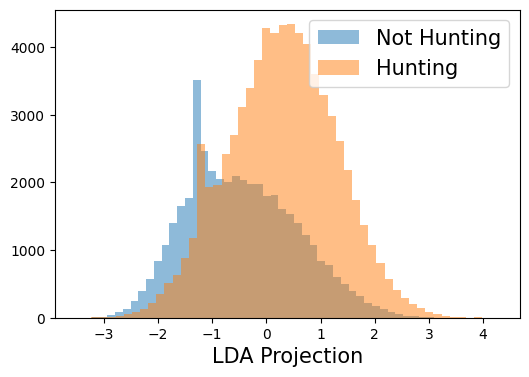

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = np.vstack(dff["rnn_states"].values)
y = dff["hunting"].astype(int).values

lda = LinearDiscriminantAnalysis(n_components=1)  # binary → 1D
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(6, 4))
plt.hist(X_lda[y==0], bins=50, alpha=0.5, label="Not Hunting")
plt.hist(X_lda[y==1], bins=50, alpha=0.5, label="Hunting")
plt.legend(fontsize=15)
plt.xlabel("LDA Projection", fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
save_dir = os.path.join(outputs_folder, "report_figures")
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "lda_hunting_projection_histogram.png"), bbox_inches="tight", dpi=300)
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

X = np.vstack(dff["rnn_states"].values)
y = dff["hunting"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, clf.predict(X_test)))
print("AUC:", roc_auc_score(y_test, clf.predict_proba(X_test)[:,1]))

In [ ]:
# # Reduce data to 2D using PCA for visualization
# pca_visual = PCA(n_components=2)
# X_train_2d = pca_visual.fit_transform(X_train)
# X_test_2d = pca_visual.transform(X_test)

# # Create a mesh grid for decision boundary
# x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
# y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
# xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# # Predict on the mesh grid
# Z = clf.predict(pca_visual.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
# Z = Z.reshape(xx.shape)

# # Plot decision boundary
# plt.figure(figsize=(10, 8))
# plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
# plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.coolwarm, label="Train")
# plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolor='k', cmap=plt.cm.coolwarm, marker='x', label="Test")
# plt.title("Logistic Regression Decision Boundary")
# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.legend()
# plt.show()

In [15]:
print(tracking_sequences_df.head())

   env_id  episode_index  agent_id  food_id  start_time_step  \
0       0              1         0       89              112   
1       0              1         0       91               74   
2       0              1         0       89              156   
3       0              1         0       90              192   
4       0              1         0       82                0   

   tracking_duration outcome  \
0                 12    miss   
1                 86    miss   
2                 29    miss   
3                 71    miss   
4                280    miss   

                                     vergence_angles  mean_vergence_angle  \
0  [53.315859568700866, 48.92041666231043, 52.791...            31.794605   
1  [50.192004079149115, 61.649864294880025, 50.43...            44.951089   
2  [23.13256917206627, 34.5798603530755, 23.12118...            40.891244   
3  [45.517732034745706, 56.78378004801516, 63.269...            55.157136   
4  [20.59999999999999, 20.59999999999

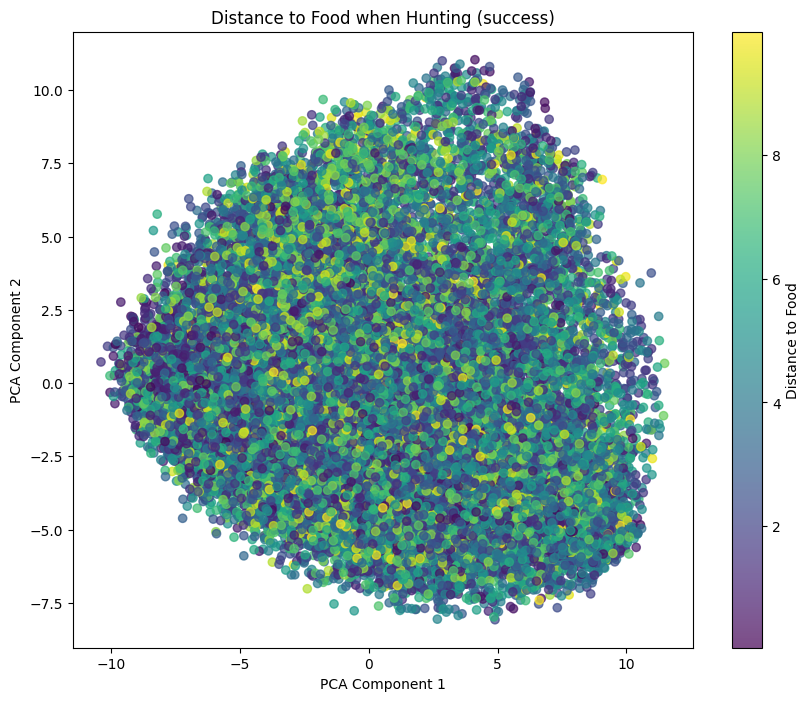

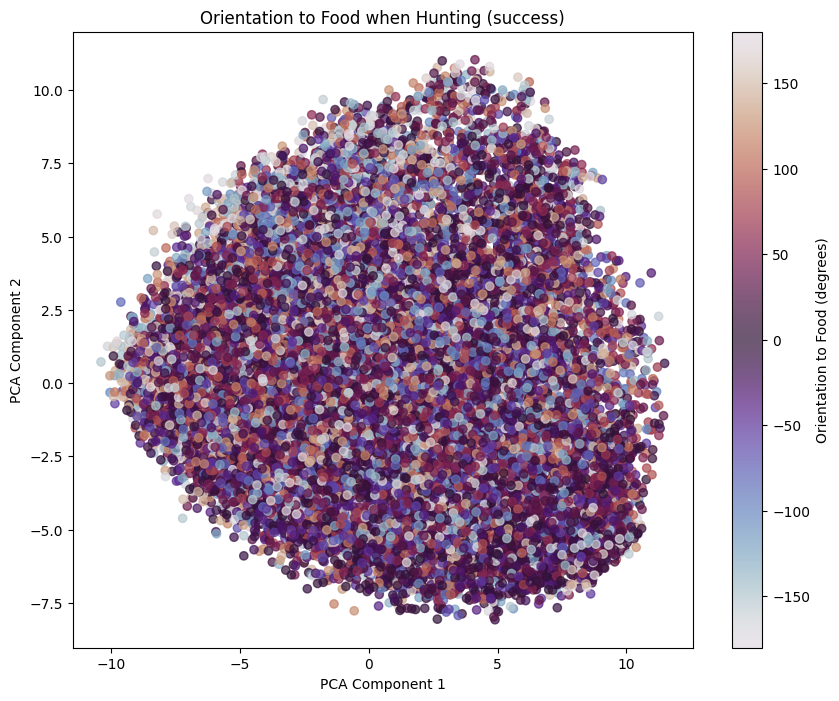

In [ ]:
# Initialize lists to store data
pca_points = []
distances_to_food = []
orientations_to_food = []

# Filter rows where both distance_to_food_hunting and angle_to_food_hunting are not NaN
mask = dff['distance_to_food_hunting'].notna() & dff['angle_to_food_hunting'].notna()
filtered_dff = dff[mask]

# Extract the data
for _, row in filtered_dff.iterrows():
    distances_to_food.append(row['distance_to_food_hunting'])
    orientations_to_food.append(row['angle_to_food_hunting'])

    # Store PCA point
    pca_points.append(pca.transform([row["rnn_states"][0]])[0])

# Convert to numpy arrays for plotting
pca_points = np.array(pca_points)
distances_to_food = np.array(distances_to_food)
orientations_to_food = np.array(orientations_to_food)

# Scatter plot colored by distance to food
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_points[:, 0], pca_points[:, 1], c=distances_to_food, cmap="viridis", alpha=0.7)
plt.colorbar(scatter, label="Distance to Food")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Distance to Food when Hunting (success)")
plt.savefig(os.path.join(save_dir, "pca_distance_to_food.png"), bbox_inches="tight", dpi=300)
plt.show()

# Scatter plot colored by orientation to food
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    pca_points[:, 0], 
    pca_points[:, 1], 
    c=orientations_to_food, 
    cmap="twilight", 
    alpha=0.7, 
    vmin=-180, 
    vmax=180
)
plt.colorbar(scatter, label="Orientation to Food (degrees)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Orientation to Food when Hunting (success)")
plt.savefig(os.path.join(save_dir, "pca_orientation_to_food.png"), bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Scatter plot colored by agent orientation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    pca_result[:, 0], 
    pca_result[:, 1], 
    c=np.log1p(dff["orientation"]-min(dff["orientation"])), 
    cmap="viridis", 
    alpha=0.7
)
plt.colorbar(scatter, label="Agent Orientation (radians)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("RNN PCA Colored by Agent Orientation")
plt.savefig(os.path.join(save_dir, "pca_agent_orientation.png"), bbox_inches="tight", dpi=300)
plt.show()